## k-Nearest Neighbor (kNN)



## kNN on Iris Dataset

Implementing the k-Nearest Neighbor (kNN) algorithm from scratch using only NumPy.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

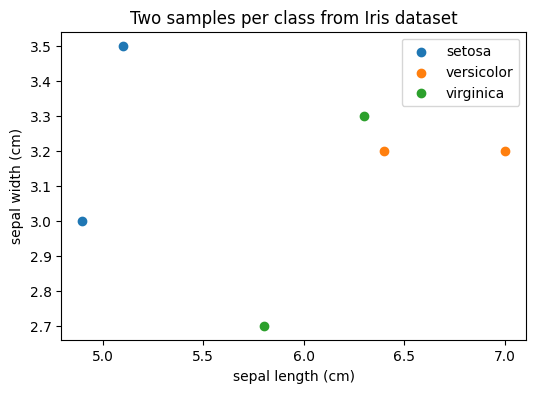

In [ ]:
# Load data and split
iris = load_iris()
X = iris.data
y = iris.target

# Plotting 2 samples per class
plt.figure(figsize=(6, 4))
for i, label in enumerate(np.unique(y)):
    plt.scatter(
        X[y == label][:2, 0], X[y == label][:2, 1],
        label=f"{iris.target_names[label]}"
    )
plt.title("Two samples per class from Iris dataset")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.show()


# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
class KNNClassifier:    # Do not rename
    """K-Nearest Neighbors classifier using only NumPy."""

    def __init__(self, k):
        """Initialize KNN classifier, providing k and the training data."""
        self.k = k

    def fit(self, X, y):
        """Fit the model using the training data."""
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        """Predict classes for multiple samples."""
        predictions = []
        for x in X:
            # Compute Euclidean distances
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

            # Find indices of k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]

            # Extract labels of these neighbors
            k_nearest_labels = self.y_train[k_indices]

            # Majority vote
            values, counts = np.unique(k_nearest_labels, return_counts=True)
            majority_label = values[np.argmax(counts)]
            predictions.append(majority_label)
        return np.array(predictions)

for k in [1, 3, 5]:
    model = KNNClassifier(k=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"k = {k}, Accuracy = {acc:.4f}")

k = 1, Accuracy = 0.9250
k = 3, Accuracy = 0.9160
k = 5, Accuracy = 0.9200


##kNN on MNIST Dataset


Accuracy (k=1): 0.9250
Accuracy (k=3): 0.9160


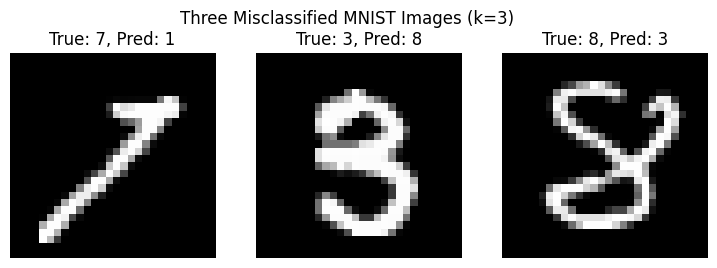

In [ ]:
from sklearn.datasets import fetch_openml

def load_mnist_subset(n_train=5000, n_test=1000, random_state=42):
    """Load a subset of MNIST dataset for faster computation."""
    # Load MNIST from OpenML
    mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto', as_frame=False)
    X = mnist['data'].astype(np.float32)
    y = mnist['target'].astype(np.int64)

    # Normalize to [0,1]
    X = X / 255.0

    # Randomly shuffle indices
    rng = np.random.RandomState(random_state)
    n_total = n_train + n_test  # default: 6000 -> 20% test
    idx = rng.permutation(X.shape[0])[:n_total]

    # Select subset and split by count
    X_sel, y_sel = X[idx], y[idx]
    X_train, y_train = X_sel[:n_train], y_sel[:n_train]
    X_test,  y_test  = X_sel[n_train:n_train + n_test], y_sel[n_train:n_train + n_test]
    return X_train, X_test, y_train, y_test

# Get data
X_train, X_test, y_train, y_test = load_mnist_subset(n_train=5000, n_test=1000, random_state=42)

class KNNClassifier:
    """K-Nearest Neighbors classifier using only NumPy."""
    def __init__(self, k):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        preds = []
        for x in X:
            dists = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_idx = np.argsort(dists)[:self.k]
            k_labels = self.y_train[k_idx]
            vals, counts = np.unique(k_labels, return_counts=True)
            preds.append(vals[np.argmax(counts)])
        return np.array(preds)

# Evaluate k = 1 and k = 3
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
results = {}
for k in [1, 3]:
    clf = KNNClassifier(k)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[k] = (y_pred, acc)
    print(f"Accuracy (k={k}): {acc:.4f}")

# Visualize 3 misclassified images for k=3
y_pred_k3 = results[3][0]
mis_idx = np.where(y_test != y_pred_k3)[0]
if len(mis_idx) > 0:
    plt.figure(figsize=(9, 3))
    for i, idx in enumerate(mis_idx[:3]):
        plt.subplot(1, 3, i + 1)
        plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        plt.title(f"True: {y_test[idx]}, Pred: {y_pred_k3[idx]}")
        plt.axis('off')
    plt.suptitle("Three Misclassified MNIST Images (k=3)")
    plt.show()
else:
    print("No misclassifications found in this sample.")